In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from PIL import Image

In [2]:
# load filtered_au_data_v2.csv
df = pd.read_csv('filtered_au_data_v2.csv')

In [3]:
# Group by Video ID and take maximum value for each AU
au_columns = [col for col in df.columns if col.startswith('AU')]
aggregated_data = df.groupby('Video ID')[au_columns].max().reset_index()

In [4]:
aggregated_data

,Video ID,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r,AU12_r,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
0,-3rGtR_J1rQ,0.23,0.00,0.00,0.00,1.50,1.87,0.70,0.87,1.63,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
1,-83rdiEyMMY,2.17,0.00,0.90,1.61,0.75,2.06,0.60,1.90,0.77,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,-9AnHP7fGng,2.58,1.00,1.30,2.95,0.72,0.82,0.24,0.32,0.22,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,-9hDaG3nJwg,0.04,0.25,0.33,0.00,0.44,2.30,1.28,1.09,0.00,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
4,-CNp8hYVIyo,4.02,3.52,0.11,0.84,0.75,1.30,0.76,2.19,1.38,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,zxplORm2L2k,0.73,0.45,1.39,1.95,0.00,0.00,4.15,0.00,0.00,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2660,zxwRkpBUczo,0.47,0.56,0.00,1.29,0.00,1.41,0.81,0.43,0.00,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
2661,zyRH0wZ83Ig,1.04,1.33,0.34,0.19,0.00,0.00,0.00,0.00,0.27,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2662,zybhU7wl2GI,1.53,1.38,1.04,0.43,1.48,2.74,0.74,2.43,2.00,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0


In [5]:
aggregated_data.columns

Index(['Video ID', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r',
       'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r',
       'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'AU01_c', 'AU02_c', 'AU04_c',
       'AU05_c', 'AU06_c', 'AU07_c', 'AU09_c', 'AU10_c', 'AU12_c', 'AU14_c',
       'AU15_c', 'AU17_c', 'AU20_c', 'AU23_c', 'AU25_c', 'AU26_c', 'AU28_c',
       'AU45_c'],
      dtype='object')

In [6]:
# drop AUs ending with '_c' suffix
aggregated_data = aggregated_data[aggregated_data.columns.drop(list(aggregated_data.filter(regex='_c')))]
aggregated_data

,Video ID,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r,AU12_r,AU14_r,AU15_r,AU17_r,AU20_r,AU23_r,AU25_r,AU26_r,AU45_r
0,-3rGtR_J1rQ,0.23,0.00,0.00,0.00,1.50,1.87,0.70,0.87,1.63,1.46,0.00,2.37,1.93,0.87,0.00,0.00,0.56
1,-83rdiEyMMY,2.17,0.00,0.90,1.61,0.75,2.06,0.60,1.90,0.77,0.58,1.47,0.80,0.00,3.40,0.95,0.49,0.00
2,-9AnHP7fGng,2.58,1.00,1.30,2.95,0.72,0.82,0.24,0.32,0.22,1.72,0.73,0.65,1.74,1.02,1.21,3.47,0.69
3,-9hDaG3nJwg,0.04,0.25,0.33,0.00,0.44,2.30,1.28,1.09,0.00,0.35,2.29,2.37,0.00,1.01,0.00,0.00,0.50
4,-CNp8hYVIyo,4.02,3.52,0.11,0.84,0.75,1.30,0.76,2.19,1.38,0.45,0.30,0.00,0.41,0.00,0.72,1.25,0.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,zxplORm2L2k,0.73,0.45,1.39,1.95,0.00,0.00,4.15,0.00,0.00,0.86,1.01,5.00,0.82,0.00,1.42,1.60,0.25
2660,zxwRkpBUczo,0.47,0.56,0.00,1.29,0.00,1.41,0.81,0.43,0.00,0.14,0.30,1.63,0.00,0.34,0.09,0.45,0.00
2661,zyRH0wZ83Ig,1.04,1.33,0.34,0.19,0.00,0.00,0.00,0.00,0.27,0.33,0.92,1.14,0.75,0.27,0.00,0.00,0.00
2662,zybhU7wl2GI,1.53,1.38,1.04,0.43,1.48,2.74,0.74,2.43,2.00,2.40,0.86,0.19,0.61,0.48,1.65,2.41,1.74


In [7]:
# check for missing values
aggregated_data.isnull().sum()

Video ID    0
AU01_r      0
AU02_r      0
AU04_r      0
AU05_r      0
AU06_r      0
AU07_r      0
AU09_r      0
AU10_r      0
AU12_r      0
AU14_r      0
AU15_r      0
AU17_r      0
AU20_r      0
AU23_r      0
AU25_r      0
AU26_r      0
AU45_r      0
dtype: int64

In [8]:
# Prepare data for clustering
def prepare_data_for_clustering(df):
    """Prepare the data for clustering by separating features and scaling"""
    # Extract features (color percentages) and image names
    X = df.drop('Video ID', axis=1).values
    image_names = df['Video ID'].values
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, image_names, scaler

X_scaled, image_names, scaler = prepare_data_for_clustering(aggregated_data)

Silhouette score for k=2: 0.1574456629151039
Silhouette score for k=3: 0.1513562066272065
Silhouette score for k=4: 0.12603394486578642
Silhouette score for k=5: 0.12959374559190562
Silhouette score for k=6: 0.11896495994762023
Silhouette score for k=7: 0.09611781645109989
Silhouette score for k=8: 0.10110040937278703
Silhouette score for k=9: 0.09218028604809045
Silhouette score for k=10: 0.0935702078182837


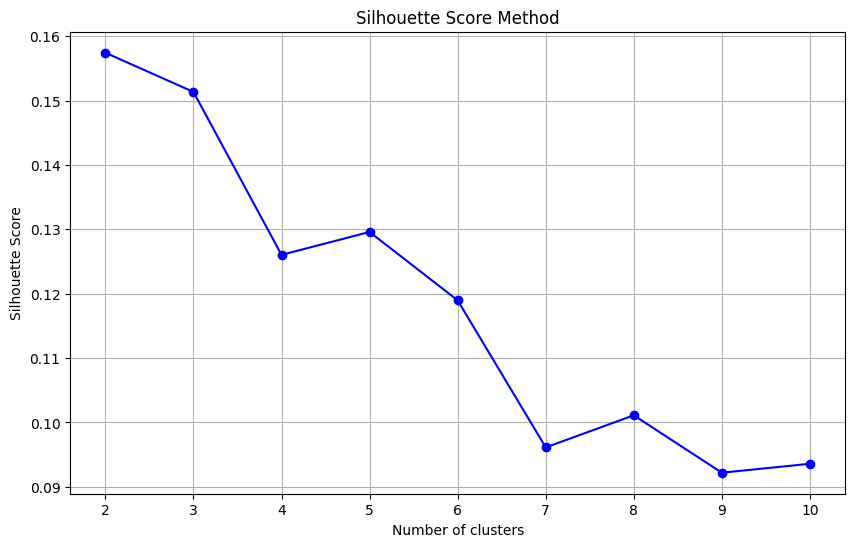

Optimal number of clusters: 2


In [9]:
# Find optimal number of clusters using silhouette score
def find_optimal_clusters(X, max_k=10):
    """Determine the optimal number of clusters using silhouette score"""
    silhouette_scores = []
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        score = silhouette_score(X, kmeans.labels_)
        silhouette_scores.append(score)
        print(f"Silhouette score for k={k}: {score}")
    
    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_k + 1), silhouette_scores, 'bo-')
    plt.title('Silhouette Score Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()
    
    # Return the optimal k (adding 2 because we start at k=2)
    return silhouette_scores.index(max(silhouette_scores)) + 2

# Find optimal number of clusters
optimal_k = find_optimal_clusters(X_scaled)
print(f"Optimal number of clusters: {optimal_k}")

In [10]:
# Perform clustering with optimal k
def perform_clustering(X, k):
    """Perform KMeans clustering"""
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    return kmeans, labels

kmeans, labels = perform_clustering(X_scaled, optimal_k)

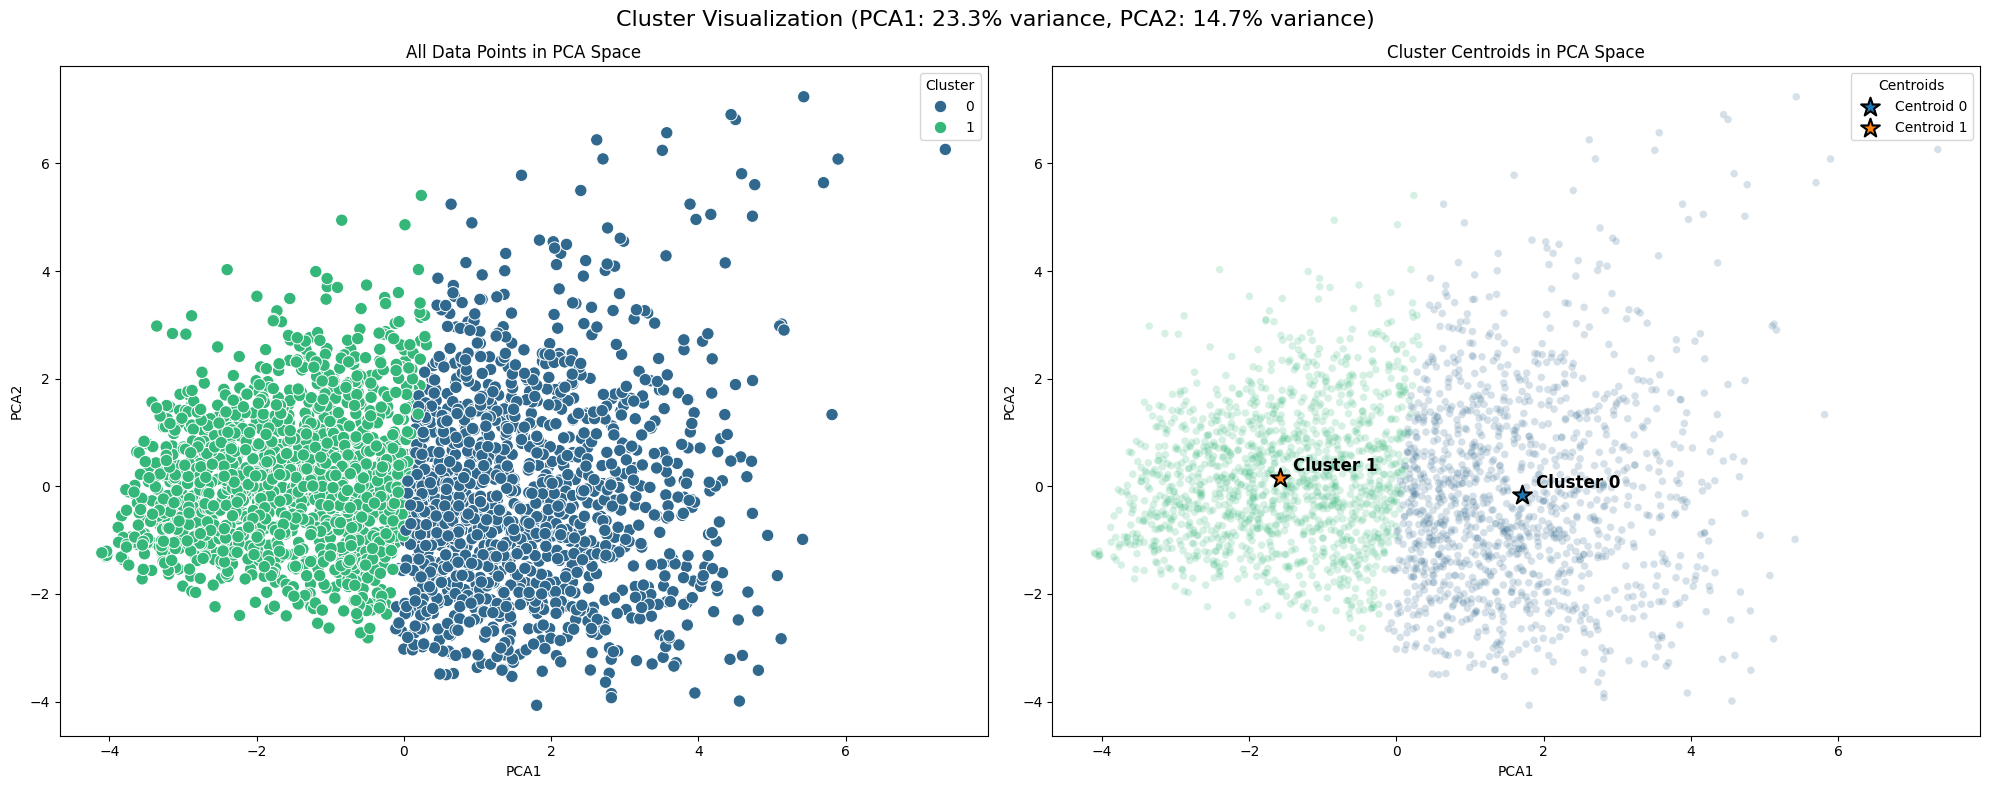

In [11]:
def visualize_clusters_pca_with_centroids(X, labels, image_names):
    """Visualize clusters in 2D using PCA with a side-by-side plot showing centroids"""
    # Apply PCA to reduce to 2 dimensions for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Create DataFrame for easier plotting
    pca_df = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 
                          'Cluster': labels, 'Image': image_names})
    
    # Calculate cluster centroids in original space
    n_clusters = len(np.unique(labels))
    centroids_orig = np.zeros((n_clusters, X.shape[1]))
    
    for i in range(n_clusters):
        centroids_orig[i] = np.mean(X[labels == i], axis=0)
    
    # Project centroids onto PCA space
    centroids_pca = pca.transform(centroids_orig)
    
    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Left plot: All data points
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', s=80, ax=ax1)
    ax1.set_title('All Data Points in PCA Space')
    ax1.legend(title='Cluster')
    
    # Right plot: Centroids only
    # First plot all points with reduced opacity for context
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', 
                   s=30, alpha=0.2, legend=False, ax=ax2)
    
    # Then plot centroids as larger points with labels
    for i in range(n_clusters):
        ax2.scatter(centroids_pca[i, 0], centroids_pca[i, 1], s=200, c=f'C{i}', 
                   marker='*', edgecolors='black', linewidth=1.5, label=f'Centroid {i}')
        ax2.annotate(f'Cluster {i}', (centroids_pca[i, 0], centroids_pca[i, 1]),
                   xytext=(10, 5), textcoords='offset points', fontsize=12, fontweight='bold')
    
    ax2.set_title('Cluster Centroids in PCA Space')
    ax2.legend(title='Centroids', loc='upper right')
    
    # Add information about variance explained
    explained_var = pca.explained_variance_ratio_
    fig.suptitle(f'Cluster Visualization (PCA1: {explained_var[0]:.1%} variance, PCA2: {explained_var[1]:.1%} variance)',
                fontsize=16)
    
    plt.tight_layout()
    plt.show()
    
    return pca, X_pca, centroids_pca

# Call the updated function
pca, X_pca, centroids_pca = visualize_clusters_pca_with_centroids(X_scaled, labels, image_names)

In [12]:
# Add cluster labels back to original data
aggregated_data = aggregated_data.assign(cluster=labels)
aggregated_data

,Video ID,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r,AU12_r,AU14_r,AU15_r,AU17_r,AU20_r,AU23_r,AU25_r,AU26_r,AU45_r,cluster
0,-3rGtR_J1rQ,0.23,0.00,0.00,0.00,1.50,1.87,0.70,0.87,1.63,1.46,0.00,2.37,1.93,0.87,0.00,0.00,0.56,1
1,-83rdiEyMMY,2.17,0.00,0.90,1.61,0.75,2.06,0.60,1.90,0.77,0.58,1.47,0.80,0.00,3.40,0.95,0.49,0.00,1
2,-9AnHP7fGng,2.58,1.00,1.30,2.95,0.72,0.82,0.24,0.32,0.22,1.72,0.73,0.65,1.74,1.02,1.21,3.47,0.69,1
3,-9hDaG3nJwg,0.04,0.25,0.33,0.00,0.44,2.30,1.28,1.09,0.00,0.35,2.29,2.37,0.00,1.01,0.00,0.00,0.50,1
4,-CNp8hYVIyo,4.02,3.52,0.11,0.84,0.75,1.30,0.76,2.19,1.38,0.45,0.30,0.00,0.41,0.00,0.72,1.25,0.43,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,zxplORm2L2k,0.73,0.45,1.39,1.95,0.00,0.00,4.15,0.00,0.00,0.86,1.01,5.00,0.82,0.00,1.42,1.60,0.25,1
2660,zxwRkpBUczo,0.47,0.56,0.00,1.29,0.00,1.41,0.81,0.43,0.00,0.14,0.30,1.63,0.00,0.34,0.09,0.45,0.00,1
2661,zyRH0wZ83Ig,1.04,1.33,0.34,0.19,0.00,0.00,0.00,0.00,0.27,0.33,0.92,1.14,0.75,0.27,0.00,0.00,0.00,1
2662,zybhU7wl2GI,1.53,1.38,1.04,0.43,1.48,2.74,0.74,2.43,2.00,2.40,0.86,0.19,0.61,0.48,1.65,2.41,1.74,0


In [13]:
# Create a function to identify the most distinctive features per cluster
def get_distinctive_features(centers_df, top_n=5):
    distinctive_features = {}
    
    for i in range(centers_df.shape[0]):
        # Calculate how much each feature in this cluster differs from its average across all clusters
        diff_from_mean = centers_df.iloc[i] - centers_df.mean()
        # Get the top N features where this cluster is higher than average
        top_high = diff_from_mean.nlargest(top_n)
        # Get the top N features where this cluster is lower than average
        top_low = diff_from_mean.nsmallest(top_n)
        
        distinctive_features[f'Cluster {i}'] = {
            'higher_than_avg': top_high.to_dict(),
            'lower_than_avg': top_low.to_dict()
        }
    
    return distinctive_features

centers = kmeans.cluster_centers_
au_columns = [col for col in aggregated_data.columns if col.startswith('AU')]
centers_df = pd.DataFrame(centers, columns=au_columns)
distinctive_features = get_distinctive_features(centers_df)

# Map AUs to facial expressions for easier interpretation
au_meaning = {
    'AU01': 'Inner Brow Raiser',
    'AU02': 'Outer Brow Raiser',
    'AU04': 'Brow Lowerer',
    'AU05': 'Upper Lid Raiser',
    'AU06': 'Cheek Raiser',
    'AU07': 'Lid Tightener',
    'AU09': 'Nose Wrinkler',
    'AU10': 'Upper Lip Raiser',
    'AU12': 'Lip Corner Puller (Smile)',
    'AU14': 'Dimpler',
    'AU15': 'Lip Corner Depressor',
    'AU17': 'Chin Raiser',
    'AU20': 'Lip Stretcher',
    'AU23': 'Lip Tightener',
    'AU25': 'Lips Part',
    'AU26': 'Jaw Drop',
    'AU45': 'Blink'
}

# Print cluster insights with AU meanings
print("\n===== CLUSTER ANALYSIS =====")
for cluster, features in distinctive_features.items():
    print(f"\n{cluster} Distinctive Features:")
    
    print("  Higher than average intensity:")
    for feature, value in features['higher_than_avg'].items():
        au_code = feature.split('_')[0]  # Extract AU code from feature name
        meaning = au_meaning.get(au_code, "Unknown")
        print(f"    {feature}: {value:.2f} - {meaning}")
    
    print("  Lower than average intensity:")
    for feature, value in features['lower_than_avg'].items():
        au_code = feature.split('_')[0]
        meaning = au_meaning.get(au_code, "Unknown")
        print(f"    {feature}: {value:.2f} - {meaning}")


===== CLUSTER ANALYSIS =====

Cluster 0 Distinctive Features:
  Higher than average intensity:
    AU06_r: 0.73 - Cheek Raiser
    AU12_r: 0.64 - Lip Corner Puller (Smile)
    AU10_r: 0.61 - Upper Lip Raiser
    AU07_r: 0.56 - Lid Tightener
    AU25_r: 0.54 - Lips Part
  Lower than average intensity:
    AU05_r: 0.04 - Upper Lid Raiser
    AU02_r: 0.04 - Outer Brow Raiser
    AU01_r: 0.10 - Inner Brow Raiser
    AU04_r: 0.16 - Brow Lowerer
    AU15_r: 0.17 - Lip Corner Depressor

Cluster 1 Distinctive Features:
  Higher than average intensity:
    AU05_r: -0.04 - Upper Lid Raiser
    AU02_r: -0.04 - Outer Brow Raiser
    AU01_r: -0.10 - Inner Brow Raiser
    AU04_r: -0.16 - Brow Lowerer
    AU15_r: -0.17 - Lip Corner Depressor
  Lower than average intensity:
    AU06_r: -0.73 - Cheek Raiser
    AU12_r: -0.64 - Lip Corner Puller (Smile)
    AU10_r: -0.61 - Upper Lip Raiser
    AU07_r: -0.56 - Lid Tightener
    AU25_r: -0.54 - Lips Part


In [14]:
# Create descriptive labels for each cluster based on the most distinctive features
cluster_descriptions = {}

for cluster, features in distinctive_features.items():
    high_expressions = []
    for feature, _ in features['higher_than_avg'].items():
        au_code = feature.split('_')[0]  # Extract AU code from feature name
        if au_code in au_meaning:
            high_expressions.append(au_meaning[au_code])
    
    if high_expressions:
        cluster_descriptions[cluster] = f"Primary expressions: {', '.join(high_expressions[:5])}"
    else:
        cluster_descriptions[cluster] = "No distinctive expressions"

print("\n===== CLUSTER INTERPRETATIONS =====")
for cluster, description in cluster_descriptions.items():
    print(f"{cluster}: {description}")


===== CLUSTER INTERPRETATIONS =====
Cluster 0: Primary expressions: Cheek Raiser, Lip Corner Puller (Smile), Upper Lip Raiser, Lid Tightener, Lips Part
Cluster 1: Primary expressions: Upper Lid Raiser, Outer Brow Raiser, Inner Brow Raiser, Brow Lowerer, Lip Corner Depressor


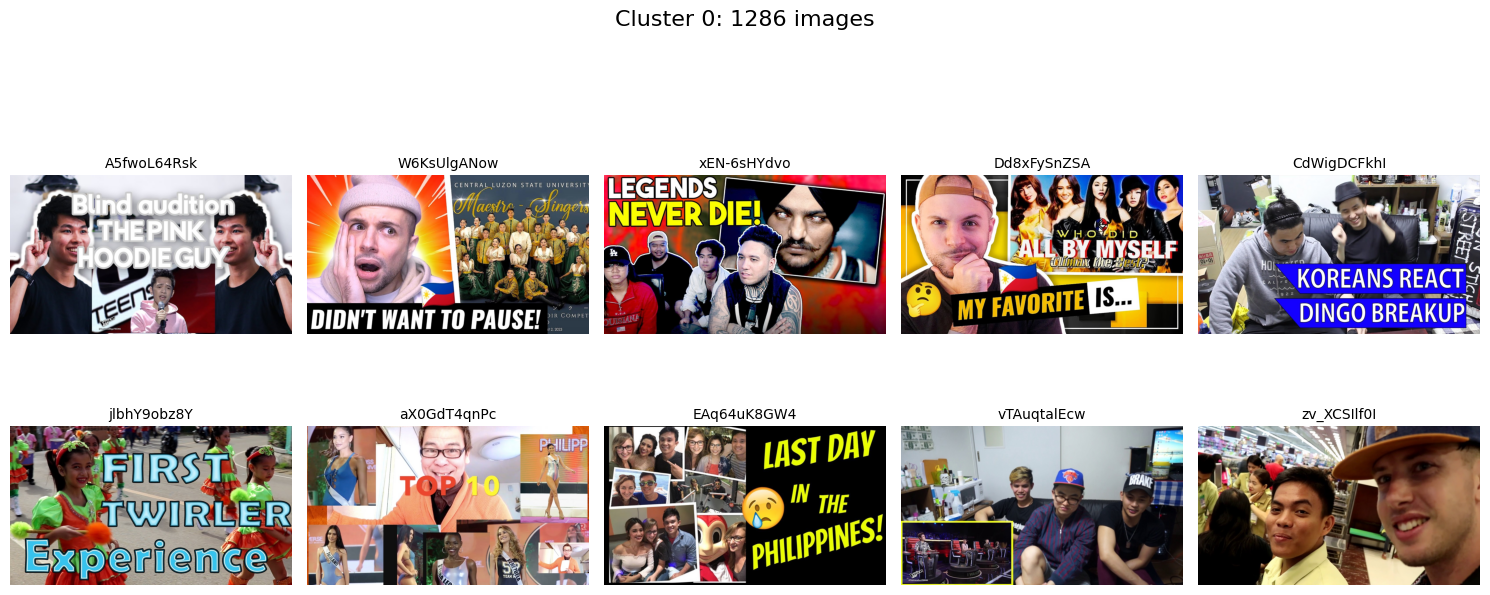

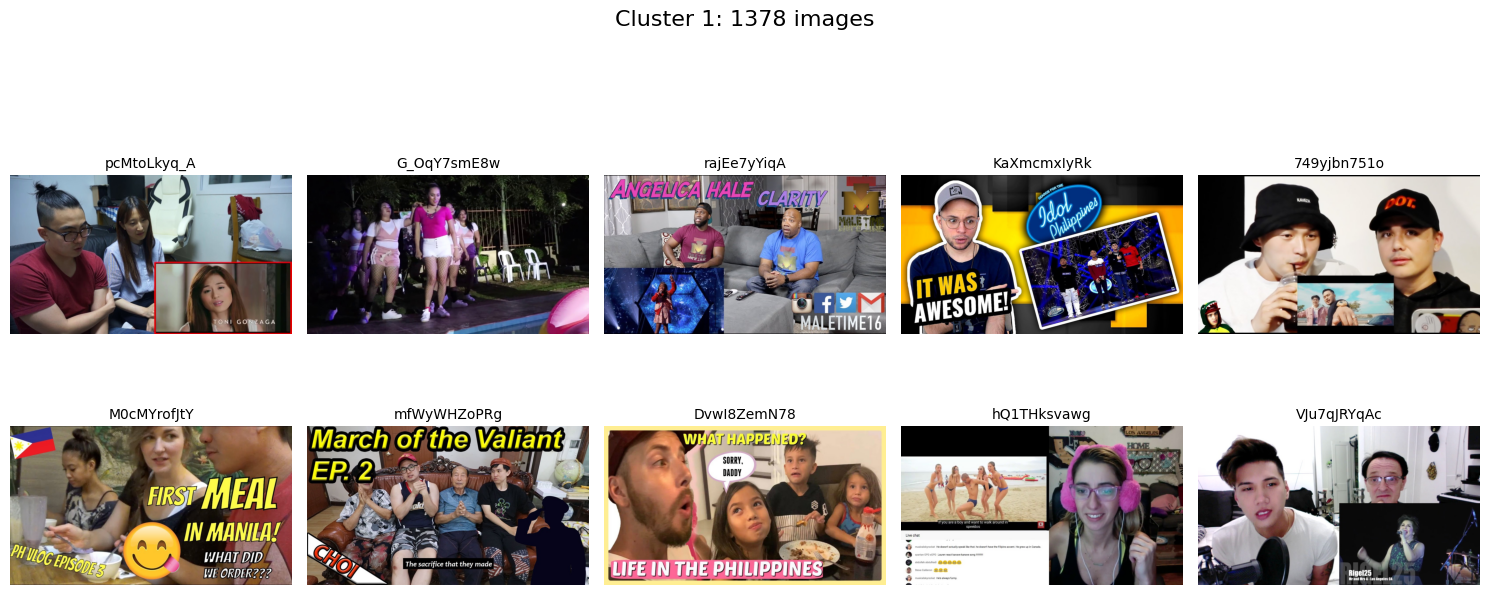

In [15]:
def find_representative_images(df_clustered, X_scaled, kmeans, n=10, images_per_row=5):
    """Find and display the most representative images in each cluster (closest to centroid)"""
    representatives = {}
    
    # Determine number of clusters and calculate cluster sizes
    n_clusters = len(kmeans.cluster_centers_)
    
    # Generate a distinct color for each cluster
    cluster_colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    # Process each cluster separately
    for cluster_id in range(n_clusters):
        # Get indices of images in this cluster
        in_cluster = df_clustered['cluster'] == cluster_id
        cluster_size = sum(in_cluster)
        
        if cluster_size == 0:
            continue
            
        # Calculate distances to centroid
        cluster_points = X_scaled[in_cluster]
        centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)
        distances = euclidean_distances(cluster_points, centroid)
        
        # Get indices of points closest to centroid
        closest_indices = np.argsort(distances.flatten())[:n]
        
        # Translate to original DataFrame indices
        original_indices = np.where(in_cluster)[0][closest_indices]
        representative_images = df_clustered.iloc[original_indices]
        
        representatives[cluster_id] = representative_images
        
        # Create a new figure for this cluster
        rows = int(np.ceil(min(n, cluster_size) / images_per_row))
        plt.figure(figsize=(images_per_row * 3, rows * 3 + 1))
        
        # Add cluster title with statistics
        plt.suptitle(f"Cluster {cluster_id}: {cluster_size} images", 
                    fontsize=16, y=0.98)
        
        # Display representative images
        for i, (idx, img) in enumerate(representative_images.iterrows()):
            if i >= n:
                break
                
            ax = plt.subplot(rows, images_per_row, i + 1)
            
            # Add colored border based on cluster
            ax.spines['bottom'].set_color(cluster_colors[cluster_id])
            ax.spines['top'].set_color(cluster_colors[cluster_id]) 
            ax.spines['right'].set_color(cluster_colors[cluster_id])
            ax.spines['left'].set_color(cluster_colors[cluster_id])
            ax.spines['bottom'].set_linewidth(5)
            ax.spines['top'].set_linewidth(5) 
            ax.spines['right'].set_linewidth(5)
            ax.spines['left'].set_linewidth(5)
            
            # Clean up filename for display
            filename = img['Video ID']
            short_name = filename[:15] + '...' if len(filename) > 15 else filename
            
            # Load and display the image
            image_path = f"../thumbnails/{filename}.jpg" #! Change to your own path
            try:
                image = plt.imread(image_path)
                plt.imshow(image)
                plt.title(short_name, fontsize=10)
                plt.axis('off')
            except Exception as e:
                plt.text(0.5, 0.5, f"Missing image", ha='center', va='center')
                plt.gca().set_facecolor('#f0f0f0')  # Light gray background for missing images
                
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
        plt.show()
    
    return representatives

# Call with the new parameter for controlling images per row
representative_images = find_representative_images(aggregated_data, X_scaled, kmeans, n=10, images_per_row=5)

In [16]:
# Define emotion mappings based on AU combinations
emotion_mappings = {
    'Happiness': {
        'required': ['AU06', 'AU12'],
        'optional': ['AU25']
    },
    'Sadness': {
        'required': ['AU01', 'AU04', 'AU15'],
        'optional': ['AU17']
    },
    'Anger': {
        'required': ['AU04', 'AU07'],
        'optional': ['AU05', 'AU23', 'AU17']
    },
    'Fear': {
        'required': ['AU01', 'AU02', 'AU04'],
        'optional': ['AU05', 'AU20', 'AU26']
    },
    'Surprise': {
        'required': ['AU01', 'AU02', 'AU05'],
        'optional': ['AU26']
    },
    'Disgust': {
        'required': ['AU09', 'AU10'],
        'optional': ['AU15', 'AU17']
    },
    'Contempt': {
        'required': ['AU14'],
        'optional': []
    }
}

# Function to identify emotions in each cluster based on centroid values
def identify_emotions_in_clusters(centers_df, threshold=0.5):
    """
    Identify likely emotions in each cluster based on AU patterns in centroids.
    threshold: minimum value to consider an AU as activated
    """
    cluster_emotions = {}
    
    # Normalize the centers to 0-1 range if using raw values
    # If already standardized, might need to adjust threshold
    
    for i in range(centers_df.shape[0]):
        cluster_emotions[f'Cluster {i}'] = []
        
        # Get AUs that are notably activated in this cluster
        activated_aus = set()
        for col in centers_df.columns:
            if centers_df.iloc[i][col] > threshold:
                au_code = col.split('_')[0]
                activated_aus.add(au_code)
        
        # Check each emotion against the activated AUs
        for emotion, mapping in emotion_mappings.items():
            required_match = all(au in activated_aus for au in mapping['required'])
            # If all required AUs are present, this emotion is likely present
            if required_match and mapping['required']:  # Ensure there are required AUs to match
                optional_count = sum(1 for au in mapping['optional'] if au in activated_aus)
                confidence = (len(mapping['required']) + optional_count) / (len(mapping['required']) + len(mapping['optional']))
                cluster_emotions[f'Cluster {i}'].append((emotion, confidence))
    
    return cluster_emotions

# Apply the function to your cluster centroids
emotion_threshold = 0.5  # Adjust based on your data
cluster_emotions = identify_emotions_in_clusters(centers_df, emotion_threshold)

# Print emotions found in each cluster
print("\n===== CLUSTER EMOTION ANALYSIS =====")
for cluster, emotions in cluster_emotions.items():
    print(f"\n{cluster}:")
    if emotions:
        for emotion, confidence in sorted(emotions, key=lambda x: x[1], reverse=True):
            print(f"  {emotion} (confidence: {confidence:.2f})")
    else:
        print("  No clear emotional expressions identified")

# Print summary statistics of centroid values
print("\nCentroid value distribution:")
print(centers_df.describe())

# Print the range of values for each cluster
for i in range(centers_df.shape[0]):
    print(f"\nCluster {i} value range: {centers_df.iloc[i].min():.2f} to {centers_df.iloc[i].max():.2f}")
    print(f"Number of AUs with value > 0.5: {(centers_df.iloc[i] > 0.5).sum()}")
    print(f"Number of AUs with value > 0.25: {(centers_df.iloc[i] > 0.25).sum()}")


===== CLUSTER EMOTION ANALYSIS =====

Cluster 0:
  Happiness (confidence: 1.00)
  Contempt (confidence: 1.00)

Cluster 1:
  No clear emotional expressions identified

Centroid value distribution:
         AU01_r    AU02_r    AU04_r    AU05_r    AU06_r    AU07_r    AU09_r  \
count  2.000000  2.000000  2.000000  2.000000  2.000000  2.000000  2.000000   
mean   0.003424  0.001285  0.005763  0.001246  0.025811  0.019922  0.016171   
std    0.137226  0.051517  0.230980  0.049950  1.034492  0.798465  0.648138   
min   -0.093610 -0.035143 -0.157564 -0.034074 -0.705685 -0.544678 -0.442131   
25%   -0.045093 -0.016929 -0.075901 -0.016414 -0.339937 -0.262378 -0.212980   
50%    0.003424  0.001285  0.005763  0.001246  0.025811  0.019922  0.016171   
75%    0.051941  0.019499  0.087427  0.018906  0.391559  0.302222  0.245323   
max    0.100457  0.037714  0.169090  0.036566  0.757307  0.584522  0.474474   

         AU10_r    AU12_r    AU14_r    AU15_r    AU17_r    AU20_r    AU23_r  \
count  2.000

In [ ]:
# Add more detailed diagnostic printing
print("\n===== DETAILED AU ACTIVATION ANALYSIS =====")
for i in range(centers_df.shape[0]):
    print(f"\nCluster {i} activated AUs (threshold > {emotion_threshold}):")
    
    # Get all AUs above threshold and sort by value
    activated_aus = []
    for col in centers_df.columns:
        value = centers_df.iloc[i][col]
        if value > emotion_threshold:
            au_code = col.split('_')[0]
            meaning = au_meaning.get(au_code, "Unknown")
            activated_aus.append((col, value, meaning))
    
    # Print sorted by activation strength
    for col, value, meaning in sorted(activated_aus, key=lambda x: x[1], reverse=True):
        print(f"  {col}: {value:.2f} - {meaning}")

# Add a custom category for "Mixed Expression" common in clickbait
emotion_mappings['Exaggerated Mixed'] = {
    'required': ['AU01', 'AU02', 'AU12'],  # Combination of surprise and happiness
    'optional': ['AU05', 'AU26', 'AU06']
}

# Add a lower-threshold check for cluster 1
print("\n===== LOWER THRESHOLD ANALYSIS FOR CLUSTER 1 =====")
lower_threshold = 0.25  # Try a more sensitive threshold
activated_aus = set()
for col in centers_df.columns:
    if centers_df.iloc[1][col] > lower_threshold:
        au_code = col.split('_')[0]
        activated_aus.add(au_code)
print(f"AUs activated at threshold {lower_threshold}:")
for au in activated_aus:
    print(f"  {au} - {au_meaning.get(au, 'Unknown')}")


===== DETAILED AU ACTIVATION ANALYSIS =====

Cluster 0 activated AUs (threshold > 0.5):
  AU06_r: 0.76 - Cheek Raiser
  AU12_r: 0.67 - Lip Corner Puller (Smile)
  AU10_r: 0.63 - Upper Lip Raiser
  AU07_r: 0.58 - Lid Tightener
  AU25_r: 0.56 - Lips Part
  AU14_r: 0.52 - Dimpler

Cluster 1 activated AUs (threshold > 0.5):

===== LOWER THRESHOLD ANALYSIS FOR CLUSTER 1 =====
AUs activated at threshold 0.25:


In [20]:
# Print the actual values in Cluster 1's centroid
print("\n===== RAW CENTROID VALUES FOR CLUSTER 1 =====")
cluster1_values = centers_df.iloc[1].sort_values(ascending=False)
print(cluster1_values)

# Try an extremely low threshold just to see anything
print("\n===== VERY LOW THRESHOLD ANALYSIS FOR CLUSTER 1 =====")
very_low_threshold = 0.1
activated_aus_low = []
for col in centers_df.columns:
    value = centers_df.iloc[1][col]
    if value > very_low_threshold:
        au_code = col.split('_')[0]
        meaning = au_meaning.get(au_code, "Unknown")
        activated_aus_low.append((col, value, meaning))

# Print any AUs with even minimal activation
print(f"AUs with any minimal activation (threshold > {very_low_threshold}):")
if activated_aus_low:
    for col, value, meaning in sorted(activated_aus_low, key=lambda x: x[1], reverse=True):
        print(f"  {col}: {value:.3f} - {meaning}")
else:
    print("  No AUs detected even at very low threshold")

#  Compare the two clusters directly
print("\n===== CLUSTER COMPARISON =====")
diff = centers_df.iloc[0] - centers_df.iloc[1]
print("Top 5 AUs stronger in Cluster 0:")
print(diff.nlargest(5))
print("\nTop 5 AUs stronger in Cluster 1:")
print(diff.nsmallest(5))


===== RAW CENTROID VALUES FOR CLUSTER 1 =====
AU05_r   -0.034074
AU02_r   -0.035143
AU01_r   -0.093610
AU04_r   -0.157564
AU15_r   -0.163824
AU17_r   -0.175874
AU26_r   -0.195351
AU23_r   -0.203659
AU20_r   -0.251289
AU45_r   -0.262745
AU09_r   -0.442131
AU14_r   -0.485458
AU25_r   -0.525294
AU07_r   -0.544678
AU10_r   -0.590084
AU12_r   -0.620873
AU06_r   -0.705685
Name: 1, dtype: float64

===== VERY LOW THRESHOLD ANALYSIS FOR CLUSTER 1 =====
AUs with any minimal activation (threshold > 0.1):
  No AUs detected even at very low threshold

===== CLUSTER COMPARISON =====
Top 5 AUs stronger in Cluster 0:
AU06_r    1.462992
AU12_r    1.287163
AU10_r    1.223334
AU07_r    1.129200
AU25_r    1.089015
dtype: float64

Top 5 AUs stronger in Cluster 1:
AU05_r    0.070640
AU02_r    0.072856
AU01_r    0.194067
AU04_r    0.326655
AU15_r    0.339632
dtype: float64


In [21]:
centers_df

,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r,AU12_r,AU14_r,AU15_r,AU17_r,AU20_r,AU23_r,AU25_r,AU26_r,AU45_r
0,0.100457,0.037714,0.169090,0.036566,0.757307,0.584522,0.474474,0.633250,0.666290,0.520970,0.175808,0.188739,0.269671,0.218557,0.563721,0.209641,0.281965
1,-0.093610,-0.035143,-0.157564,-0.034074,-0.705685,-0.544678,-0.442131,-0.590084,-0.620873,-0.485458,-0.163824,-0.175874,-0.251289,-0.203659,-0.525294,-0.195351,-0.262745
